# Week 2 assignment

In this assignment the objective are to try out different model architectures and to experiement with different kinds of regularization.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.datasets import california_housing
from sklearn.model_selection import train_test_split


(inputs, targets), (x_test, y_test) = california_housing.load_data(version='large',
                                                                   test_split=0.2)

print(inputs.shape, targets.shape)
print(x_test.shape, y_test.shape)

743530/743530 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(16512, 8) (16512,)
(4128, 8) (4128,)


## Baseline method

This section establishes a baseline for our model performance. It involves several key steps:

1.  **Data Splitting**: The dataset is divided into training, validation, and test sets. The training set is used to train the model, the validation set helps tune hyperparameters and prevent overfitting during training, and the test set is used for final evaluation.
2.  **Data Preprocessing**: Input features (`x_train`, `x_val`, `x_test`) are standardized by subtracting the mean and dividing by the standard deviation of the training data. Target values (`y_train`, `y_val`, `y_test`) are scaled by dividing by `1e5` (100,000) to keep them within a reasonable range for training.
3.  **Model Architecture**: A simple Sequential neural network is defined with two `Dense` layers, each having 64 units and ReLU activation, followed by a final `Dense` layer with one unit for output. This architecture serves as our basic model.
4.  **Model Compilation**: The model is compiled using the Adam optimizer, Mean Squared Error (MSE) as the loss function, and Mean Absolute Error (MAE) as a metric. MSE is commonly used for regression tasks, and MAE provides an easily interpretable measure of error.
5.  **Model Training**: The model is trained for 100 epochs with a batch size of 32. The validation data is used to monitor performance during training, and `verbose=0` keeps the training output concise.
6.  **Performance Visualization**: Plots are generated to visualize the training and validation loss, as well as MAE, over the epochs. These plots help us understand the model's learning progress and identify signs of overfitting.

## Baseline method

In [2]:
# x_train = inputs[:380]
# y_train = targets[:380]
# x_val = inputs[380:]
# y_val = targets[380:]

x_train, x_val, y_train, y_val = train_test_split(inputs, targets, test_size=0.2, random_state=42)

In [3]:
mean = x_train.mean(axis=0)
std = x_train.std(axis=0)
x_train -= mean
x_train /= std
x_test -= mean
x_test /= std
x_val -= mean
x_val /= std
y_train /= 1e5
y_test /= 1e5
y_val /= 1e5

In [4]:
model = Sequential([
    Input(shape=(8,)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
    ])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [5]:
history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_val, y_val), verbose=0)

Text(0, 0.5, 'Loss')

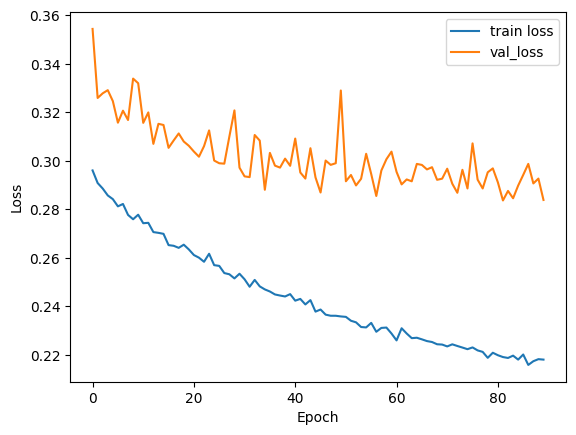

In [6]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

Text(0, 0.5, 'Mean absolute error (in 100000 $)')

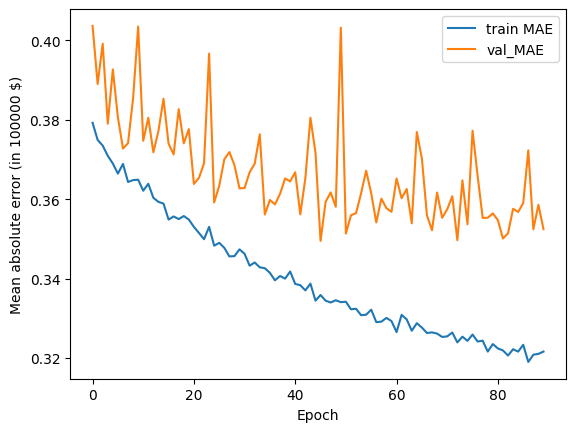

In [7]:
plt.plot(history.history['mae'][10:], label='train MAE')
plt.plot(history.history['val_mae'][10:], label='val_MAE')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Mean absolute error (in 100000 $)')

## Regularization Methods

Regularization is a technique used in machine learning to prevent overfitting by adding a penalty term to the loss function. This encourages the model to learn simpler patterns and reduces the complexity of the model, which can lead to better generalization on unseen data. Here, we will explore L2 regularization (also known as weight decay) by adding a small penalty based on the square of the weight magnitudes.

This section will demonstrate how L2 regularization impacts the model's performance, specifically comparing its loss and MAE metrics against the baseline model during training and validation.

In [8]:
from keras.regularizers import l2

model_reg = Sequential([
    Input(shape=(8,)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(1)
])

model_reg.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [9]:
history_reg = model_reg.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_val, y_val), verbose=0)

Text(0, 0.5, 'Loss')

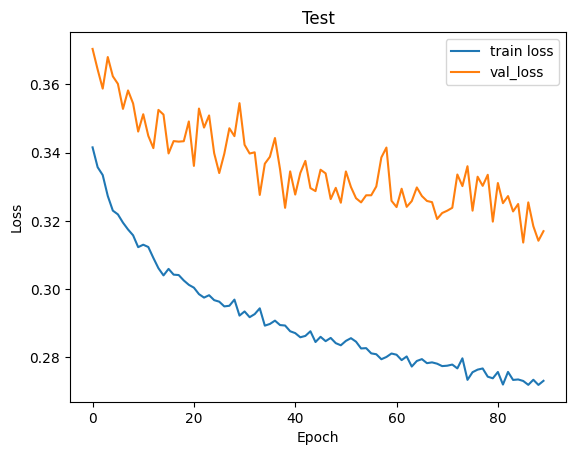

In [10]:
plt.plot(history_reg.history['loss'][10:], label='train loss')
plt.plot(history_reg.history['val_loss'][10:], label='val_loss')
plt.legend()
plt.title('Test')
plt.xlabel('Epoch')
plt.ylabel('Loss')

Text(0, 0.5, 'Mean absolute error (in 100000 $)')

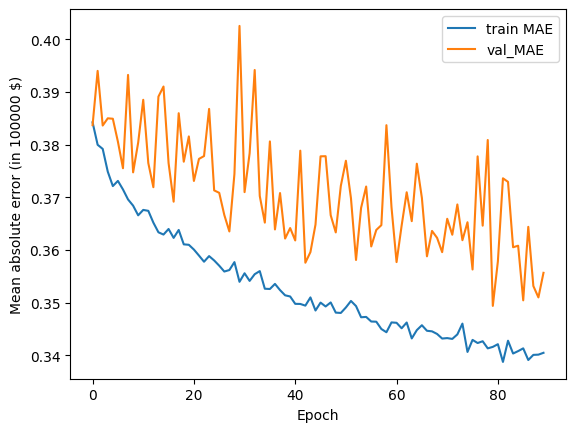

In [11]:
plt.plot(history_reg.history['mae'][10:], label='train MAE')
plt.plot(history_reg.history['val_mae'][10:], label='val_MAE')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Mean absolute error (in 100000 $)')

## Dropout

Dropout is another powerful regularization technique where randomly selected neurons are ignored during training. This means that their contribution to the activation of downstream neurons is temporarily removed, forcing the network to learn more robust features that are not dependent on the presence of any single neuron. This helps prevent complex co-adaptations on training data.

In this section, we will implement dropout layers in our neural network and analyze its effect on the training and validation loss and MAE, comparing it to the baseline and L2 regularized models.

In [12]:
from keras.layers import Dropout

model_drop = Sequential([
    Input(shape=(8,)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

In [13]:
model_drop.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [14]:
history_drop = model_drop.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_val, y_val), verbose=0)

Text(0, 0.5, 'Loss')

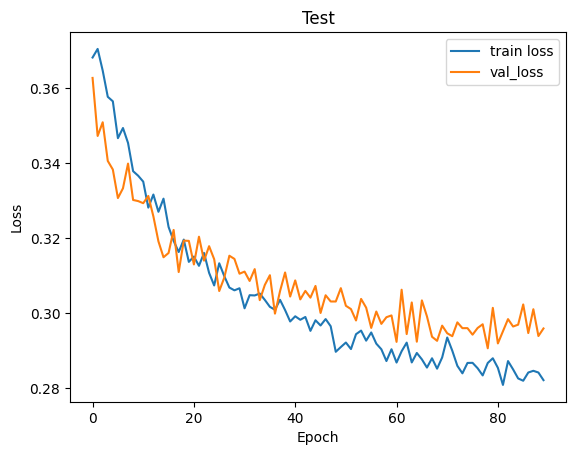

In [15]:
plt.plot(history_drop.history['loss'][10:], label='train loss')
plt.plot(history_drop.history['val_loss'][10:], label='val_loss')
plt.legend()
plt.title('Test')
plt.xlabel('Epoch')
plt.ylabel('Loss')

Text(0, 0.5, 'Mean absolute error (in 100000 $)')

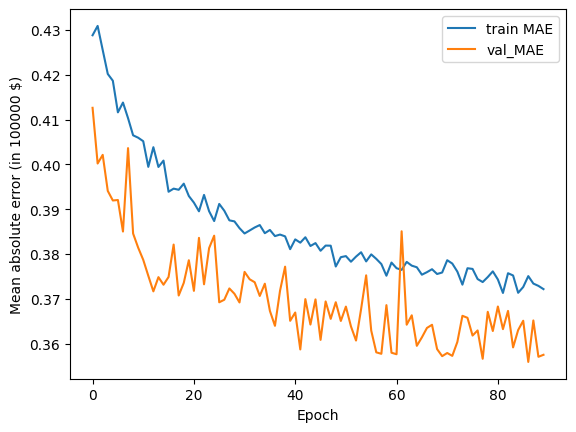

In [16]:
plt.plot(history_drop.history['mae'][10:], label='train MAE')
plt.plot(history_drop.history['val_mae'][10:], label='val_MAE')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Mean absolute error (in 100000 $)')

## Final Model Training and Evaluation

Now we determine, which model has the best performance.

In [17]:
from IPython.display import display, Markdown

final_val_mae_drop = history_drop.history['val_mae'][-1]
final_val_mae_reg = history_reg.history['val_mae'][-1]
final_val_mae_baseline = history.history['val_mae'][-1]

mae_table = f"""
### Model perfomance Summary (Final Validation MAE)
| Model        | MAE                          |
| ---          | ---                          |
| Baseline     | {final_val_mae_baseline:.2f} |
| Regularizers | {final_val_mae_reg:.2f}      |
| Dropout      | {final_val_mae_drop:.2f}     |
"""

display(Markdown(mae_table))



### Model perfomance Summary (Final Validation MAE)
| Model        | MAE                          |
| ---          | ---                          |
| Baseline     | 0.35 |
| Regularizers | 0.36      |
| Dropout      | 0.36     |


In [20]:
import numpy as np

# Determine the best model based on final validation MAE
final_val_maes = {
    'Baseline': final_val_mae_baseline,
    'Regularizers': final_val_mae_reg,
    'Dropout': final_val_mae_drop
}

best_model_name = min(final_val_maes, key=final_val_maes.get)
best_val_mae = final_val_maes[best_model_name]

print(f"The best model based on validation MAE is: {best_model_name} with MAE: {best_val_mae:.2f}")

# Combine training and validation data
x_combined_train = np.concatenate((x_train, x_val), axis=0)
y_combined_train = np.concatenate((y_train, y_val), axis=0)

print(f"Combined training data shape: {x_combined_train.shape}")
print(f"Combined training targets shape: {y_combined_train.shape}")

# Re-initialize and train the best model
if best_model_name == 'Baseline':
    final_model = Sequential([
        Input(shape=(8,)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1)
    ])
elif best_model_name == 'Regularizers':
    final_model = Sequential([
        Input(shape=(8,)),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(1)
    ])
else: # Dropout
    final_model = Sequential([
        Input(shape=(8,)),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])

final_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

print(f"Training the {best_model_name} model on combined train+validation data...")
history_final = final_model.fit(x_combined_train, y_combined_train, epochs=100, batch_size=32, verbose=0)

# Evaluate on the test set
print("Evaluating the final model on the test set...")
loss, mae = final_model.evaluate(x_test, y_test, verbose=0)

print(f"Final Test Loss: {loss:.4f}")
print(f"Final Test MAE: {mae:.4f}")

final_test_mae = mae

mae_table_final = f"""
### Model Performance Summary (Final Test MAE)
| Model        | Validation MAE               | Test MAE                 |
| ---          | ---                          | ---                      |
| Baseline     | {final_val_mae_baseline:.2f} | {f'{final_test_mae:.2f}' if best_model_name == 'Baseline' else 'N/A'} |
| Regularizers | {final_val_mae_reg:.2f}      | {f'{final_test_mae:.2f}' if best_model_name == 'Regularizers' else 'N/A'} |
| Dropout      | {final_val_mae_drop:.2f}     | {f'{final_test_mae:.2f}' if best_model_name == 'Dropout' else 'N/A'} |
\nNote: Test MAE is reported only for the best performing model based on validation set.
"""
display(Markdown(mae_table_final))


The best model based on validation MAE is: Baseline with MAE: 0.35
Combined training data shape: (16512, 8)
Combined training targets shape: (16512,)
Training the Baseline model on combined train+validation data...
Evaluating the final model on the test set...
Final Test Loss: 0.2739
Final Test MAE: 0.3469



### Model Performance Summary (Final Test MAE)
| Model        | Validation MAE               | Test MAE                 |
| ---          | ---                          | ---                      |
| Baseline     | 0.35 | 0.35 |
| Regularizers | 0.36      | N/A |
| Dropout      | 0.36     | N/A |

Note: Test MAE is reported only for the best performing model based on validation set.
